In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

model_order = [
    "ContextFold", "ContraFold", "EternaFold", "IPKnot", "NeuralFold",
    "NUPACK", "RNAFold", "RNAStructure", "pKnots", "Simfold",
    "MXFold", "MXFold2", "SPOT-RNA"
]

In [2]:
metrics_order = ["Sensitivity", "PPV", "F1"]

with open("data/canonical_bprna_master_file_0.txt") as fh:
    data = fh.readlines()

data[:2]

['bpRNA, RNAStructure, 0, bpRNA_RFAM_19360, AGUCAGUGCACCAAUACCUUGGCUCUAGACUGCUUACUGCUAAAAGUGCUCCAAAGUACAGUAACAGUCUACAGUCAUGGCUACUGACGCCUGGC, ................((.((((....(((((.(((((.....................))))))))))....)))).))..............., .(((((.((..((.((((.(((((.(((((((.(((((.......(((((....))))))))))))))))).))))).)).)).))..))))))), 1.0, 0.45714285714285713, 0.6274509803921569\n',
 'bpRNA, RNAStructure, 0, bpRNA_RFAM_27862, AUACUGAAUGUAAGGUGGGAAAUCAGUGUGAAAUUCAUUGGCUCUUCCUGGAACCGUAAAGCCGGAGCUCCACCCAGUAGAGACCGAUGUUGAAUGAAGGCCAGGAAAAGUCUAGUUCUGCAAUUAAAAA, .(((((.......(((((.....(((((.......)))))..(((....))).(((......)))....))))))))))............((((..((((........)))).))))............, (((((((...............)))))))......((((((((((..((((....((..(((....)))..)))))).)))).))))))..((((..((((........)))).))))............, 0.27586206896551724, 0.23529411764705882, 0.253968253968254\n']

In [3]:
data[0].split(", ")

['bpRNA',
 'RNAStructure',
 '0',
 'bpRNA_RFAM_19360',
 'AGUCAGUGCACCAAUACCUUGGCUCUAGACUGCUUACUGCUAAAAGUGCUCCAAAGUACAGUAACAGUCUACAGUCAUGGCUACUGACGCCUGGC',
 '................((.((((....(((((.(((((.....................))))))))))....)))).))...............',
 '.(((((.((..((.((((.(((((.(((((((.(((((.......(((((....))))))))))))))))).))))).)).)).))..)))))))',
 '1.0',
 '0.45714285714285713',
 '0.6274509803921569\n']

In [4]:
sens_idx = 7
ppv_idx = 8
f1_idx = 9

metrics = ["sens", "ppv", "f1"]

model_stat_map = {}
for m in model_order:
    model_stat_map[m] = {}
    for metric in metrics:
        model_stat_map[m][metric] = []

data = [d.split(", ") for d in data]

metric_coords = [("sens", 7), ("ppv", 8), ("f1", 9)]
for d in data:
    model = d[1]
    for metric, idx in metric_coords:
        val = float(d[idx].strip())
        model_stat_map[model][metric].append(val)



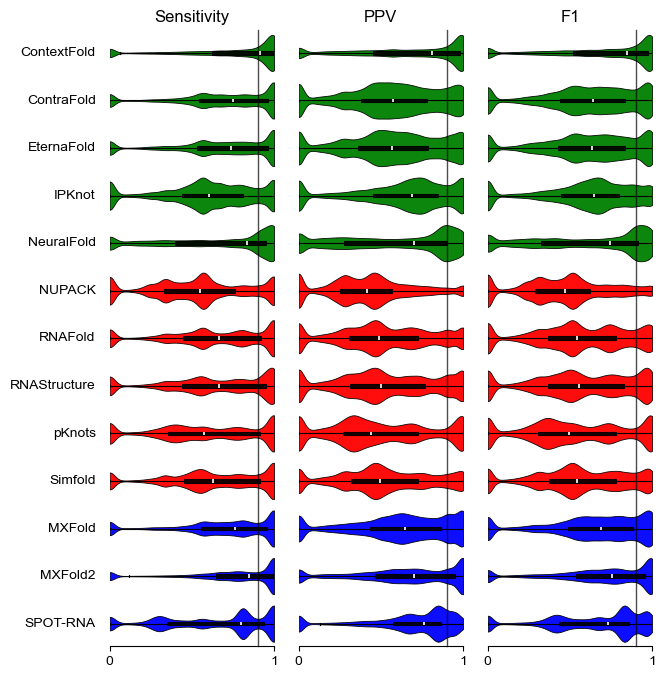

In [5]:
import data_utils as du

m_pretty_key_map = {"Sensitivity": "sens", "PPV": "ppv", "F1": "f1"}

n_rows = len(model_order)
n_cols = len(metrics_order)

fig_w = max(1.8 * n_cols, 7)
fig_h = max(0.4 * n_rows, 8)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_w, fig_h),
    squeeze=False,
    sharex=False,
    sharey=False
)

for row_idx, model in enumerate(model_order):
    model_color = du.get_model_color(model)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    for col_idx, metric in enumerate(metrics_order):
        ax = axes[row_idx, col_idx]

        metric_key = m_pretty_key_map[metric]
        values = model_stat_map[model][metric_key]
        values = [v for v in values if v is not None and not np.isnan(v)]

        violin = ax.violinplot(
            values,
            positions=[0],
            widths=0.8,
            showmeans=False,
            showmedians=False,
            showextrema=False,
            vert=False
        )

        for body in violin["bodies"]:
            body.set_facecolor(model_color)
            body.set_edgecolor("black")
            body.set_alpha(0.95)
            body.set_linewidth(0.6)

        # Add inner boxplot inside the violin
        box = ax.boxplot(
            values,
            positions=[0],
            widths=0.08,
            vert=False,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(
                facecolor="black",
                edgecolor="black",
                linewidth=0.8,
                alpha=0.9
            ),
            medianprops=dict(
                color="white",
                linewidth=1.2
            ),
            whiskerprops=dict(
                color="black",
                linewidth=0.8
            ),
            capprops=dict(
                color="black",
                linewidth=0.8
            )
        )

        if "cmedians" in violin:
            violin["cmedians"].set_color("black")
            violin["cmedians"].set_linewidth(1.0)


        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.5, 0.5)

        if row_idx == n_rows - 1:
            ax.set_xticks([0.0, 1.0])
        else:
            ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(axis="y", alpha=0.2, linewidth=0.5)

        for spine in ax.spines.values():
            spine.set_visible(False)

        if row_idx == n_rows - 1:
            ax.spines["bottom"].set_visible(True)
            ax.spines["bottom"].set_linewidth(0.8)
            ax.spines["bottom"].set_color("black")

        if col_idx == 0:
            ax.set_ylabel(model, rotation=0, ha="right", va="center", labelpad=10)


        if row_idx == 0:
            ax.set_title(metric)

# plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.15)

fig.canvas.draw()
threshold = 0.9

for col_idx in range(n_cols):
    top_ax = axes[0, col_idx]
    bottom_ax = axes[-1, col_idx]

    # Convert x=0.9 from data coordinates to figure coordinates
    x_display = top_ax.transData.transform((threshold, 0))[0]
    x_fig = fig.transFigure.inverted().transform((x_display, 0))[0]

    # Get vertical span of the whole column in figure coordinates
    y_bottom = bottom_ax.get_position().y0
    y_top = top_ax.get_position().y1

    line = Line2D(
        [x_fig, x_fig],
        [y_bottom, y_top],
        transform=fig.transFigure,
        color="black",
        linewidth=1,
        alpha=0.7,
        zorder=10
    )

    fig.add_artist(line)

plt.savefig("bprna_violin_plot.png", dpi=500)
plt.show()
